## Spin Coherence Time by Mapping Method

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import ScalarFormatter

## Data Structure and Path Configuration

This section defines the data acquisition environment and the internal structure of the input files used for the spin tune analysis.

### 1. Root Directory and Lattice List
*   **Root Path**: `root_path` specifies the local repository containing the COSY Infinity simulation results.
*   **Lattice Structures**: The `lattices` list contains the identifiers for the different magnet configurations to be analyzed:
    *   `magnetic_2p` / `magnetic_sextupoles`: Standard magnetic configurations.
    *   `electrostatic`: Purely electric field lattice.
    *   `Nuclotron_8` / `Nuclotron_16`: Complex accelerator lattices with specific periodicity.

### 2. Input File Schema (Column Definitions)
The analysis relies on three types of data files for each lattice and mode. The following column definitions ensure correct parsing of the raw `.dat` files:

*   **Integrals (`cols_int`)**: Contains the control and observation parameters:
    *   `SGx1, SGx2, SGy1, SGy2`: Sextupole current families (Control Parameters).
    *   `chrom_x, chrom_y`: Transverse chromaticities.
    *   `eta_1`: The longitudinal slip factor component.
    *   `quad_Kx, quad_Ky, quad_Kz`: Quadrupole strength components.
*   **Spin Tunes for Particle 0 (`cols_s0`)**:
    *   `spin_ref`: The reference spin tune for the on-orbit particle.
    *   `spin_x, spin_y, spin_z`: The calculated spin tune response components.
*   **Spin Tunes for Particle 1 (`cols_s1`)**:
    *   `spin_ref_1`: The reference spin tune for the off-orbit particle.
    *   `spin_x_1, spin_y_1, spin_z_1`: The spin tune response for the second particle.

### 3. Simulation Ranges and Constraints
The response analysis is performed by scanning one parameter while enforcing zero-constraints on the others to ensure cross-plane decoupling:

*   **Scanned Ranges**:
    *   Horizontal ($\xi_x$): From $-10$ to $10$.
    *   Vertical ($\xi_y$): From $-10$ to $10$.
    *   Longitudinal ($\eta_1$): From $-1$ to $1$.
*   **Decoupling Constraints**:
    *   **$x$-plane**: Analyzed while maintaining $\xi_y=0$ and $\eta_1=0$.
    *   **$y$-plane**: Analyzed while maintaining $\xi_x=0$ and $\eta_1=0$.
    *   **$z$-plane**: Analyzed while maintaining $\xi_x=0$ and $\xi_y=0$.


In [135]:
plt.rcParams.update({'font.size': 10, 'axes.grid': True})

root_path = 'C:/GIT_REPOS/SCT/COSY/src/dat/'
lattices = ['magnetic_2p','magnetic_sextupoles', 'electrostatic','Nuclotron_8', 'Nuclotron_16',] 

# --- Plotting Configuration ---
steps = 100
ranges = [np.linspace(-10, 10, steps), np.linspace(-10, 10, steps), np.linspace(-1, 1, steps)]
labels = [r'$\xi_x$', r'$\xi_y$', r'$\eta_1$']
colors = ['red', 'blue', 'green']
plane_names = ['x', 'y', 'z']
# Specific constraints for cross-plane decoupling
constraints = [r'$\xi_y=0, \eta_1=0$', r'$\xi_x=0, \eta_1=0$', r'$\xi_x=0, \xi_y=0$']


cols_int = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'chrom_x', 'chrom_y', 'MU_ref', 'quad_Kx', 'quad_Ky', 'quad_Kz', 'alpha_0', 'alpha_1', 'eta_1']
cols_s0  = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'spin_ref', 'spin_x', 'spin_y', 'spin_z']
cols_s1  = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'spin_ref_1', 'spin_x_1', 'spin_y_1', 'spin_z_1']

## Data Loading and Preprocessing

The `get_data` function automates the acquisition and cleaning of simulation results for a given lattice and field mode.

### 1. File Acquisition
The function locates three mandatory files per configuration:
*   `integrals`: Control parameters and chromaticities.
*   `particle_spin_tune`: Spin response for the reference particle (P0).
*   `particle_spin_tune_1`: Spin response for the off-orbit particle (P1).

### 2. Numerical Cleaning
To ensure compatibility between **COSY Infinity** output and **Python**, the function:
*   Replaces the Fortran double-precision exponent `D` with the standard scientific `E`.
*   Converts all raw string data into numeric floats.
*   Removes any incomplete rows (NaNs) to maintain matrix integrity.

### 3. Data Merging
The three datasets are joined into a single master DataFrame using the **sextupole current families** (`SGx1, SGx2, SGy1, SGy2`) as unique keys. This synchronization ensures that each spin-tune measurement is mapped to its corresponding chromaticity state.


In [136]:
def get_data(lattice, mode):
    """
    Loads and cleans experimental data from three separate .dat files.
    
    Parameters:
    lattice (str): Folder name for the specific magnet structure (e.g., 'Nuclotron_8').
    mode (str): Field configuration mode ('FR0' for ideal, 'FR3' for fringe fields).
    
    Returns:
    pd.DataFrame: A single merged DataFrame containing integrals and spin tunes for 2 particles.
    """
    base = os.path.join(root_path, lattice)
    
    # Define file paths for integrals, particle 0 spin tune, and particle 1 spin tune
    f = {
        'int': f'{base}/integrals_{mode}.dat', 
        's0':  f'{base}/particle_spin_tune_{mode}.dat', 
        's1':  f'{base}/particle_spin_tune_1_{mode}.dat'
    }
    
    # Check if all required files exist before proceeding
    if not all(os.path.exists(p) for p in f.values()): 
        print(f"Warning: Missing files in {base} for mode {mode}")
        return None

    dfs = {}
    for k, p in f.items():
        # Assign correct column headers based on file type
        c = cols_int if k == 'int' else (cols_s0 if k == 's0' else cols_s1)
        
        # Load the space-separated values file
        tmp = pd.read_csv(p, sep=r'\s+', names=c, engine='python')
        
        # DATA CLEANING:
        # 1. Convert Fortran double precision exponents ('D') to Python standard ('E')
        # 2. Convert string representations to numeric floats
        # 3. Drop any rows containing NaN values to ensure matrix stability
        for col in tmp.columns: 
            tmp[col] = pd.to_numeric(tmp[col].astype(str).str.replace('D', 'E'), errors='coerce')
        dfs[k] = tmp.dropna()

    # MERGING PROCESS:
    # We use the sextupole currents (SGx1, SGx2, SGy1, SGy2) as unique keys 
    # to align integrals and spin tune data for both particles.
    m = pd.merge(dfs['int'], dfs['s0'], on=['SGx1', 'SGx2', 'SGy1', 'SGy2'])
    return pd.merge(m, dfs['s1'], on=['SGx1', 'SGx2', 'SGy1', 'SGy2'])

## Linear Response Model Mathematics

The analysis approximates the relationship between control parameters (sextupole currents) and machine observables (spin tunes and chromaticities) using a **Linear Response Model** solved via **Ordinary Least Squares (OLS)**.

### 1. Design Matrix Construction ($\mathbf{X}$)
The control vector $\vec{I}$ represents the three independent sextupole families:
$$\vec{I} = [SG_{x1}, SG_{x2}, SG_{y1}]^T$$

For a dataset containing $n$ observations, we construct the design matrix $\mathbf{X}$ (size $n \times 4$). The first three columns contain the input currents, and the final column consists of ones to account for the intercept (the state of the machine when all magnets are off):

$$\mathbf{X} = \begin{pmatrix} 
SG_{x1,1} & SG_{x2,1} & SG_{y1,1} & 1 \\
SG_{x1,2} & SG_{x2,2} & SG_{y1,2} & 1 \\
\vdots & \vdots & \vdots & \vdots \\
SG_{x1,n} & SG_{x2,n} & SG_{y1,n} & 1 
\end{pmatrix}$$

### 2. Observation Matrices ($\mathbf{Y}_{spin}$ and $\mathbf{Y}_{chrom}$)
These matrices contain the raw "measured" data from your simulation files.
*   **$\mathbf{Y}_{spin}$** (size $n \times 3$): Each row contains the observed spin tune components $(x, y, z)$.
*   **$\mathbf{Y}_{chrom}$** (size $n \times 3$): Each row contains the observed chromaticity components $(\xi_x, \xi_y, \eta_1)$.

### 3. Solving for Coefficients ($\beta$)
The "Solving" process aims to find the coefficient matrix $\beta$ that best maps our inputs ($\mathbf{X}$) to our observations ($\mathbf{Y}$). We solve the system:
$$\mathbf{X} \cdot \beta \approx \mathbf{Y}$$

In the code, `np.linalg.lstsq` finds the $\beta$ matrix that minimizes the residual sum of squares:
$$\min_{\beta} \|\mathbf{Y} - \mathbf{X}\beta\|^2$$

### 4. Parameter Extraction from $\beta$
The resulting matrix $\beta$ (size $4 \times 3$) contains all the physics of the response. We "slice" this matrix to separate the slopes from the offsets:

*   **Response Matrix ($R$):** These are the first three rows of $\beta$. They represent the **Slopes** (sensitivity). 
    *   *Physical meaning:* How many units the spin/chromaticity changes per 1 unit of current.
    *   In the code: `R = beta[:3, :].T` (Transposed to match the $3 \times 3$ Jacobian format).
    *   **$\mathbf{R}_{spin}$**: Spin Jacobian.
    *   **$\mathbf{R}_{int}$**: Chromaticity Jacobian.

*   **Intercept Vector (nat):** This is the fourth (last) row of $\beta$. It represents the **Offsets**.
    *   *Physical meaning:* The "Natural" value of spin or chromaticity when all sextupoles are zero ($I=0$).
    *   In the code: `nat = beta[3, :]`.
    *   **$\vec{b}_{spin}$**: Natural spin tune.
    *   **$\vec{d}_{int}$**: Natural chromaticity.

### 5. Final Model Equations
Once extracted, the models allow us to predict the machine state for any current $\vec{I}$:
$$\vec{\xi} = \mathbf{R}_{int} \cdot \vec{I} + \vec{d}_{int}$$
$$\Delta\vec{\nu}_s = \mathbf{R}_{spin} \cdot \vec{I} + \vec{b}_{spin}$$


In [138]:
def get_dual_model(df, suffix=''):
    """
    Constructs the linear response model for a specific particle.
    
    R_spin:   3x3 Matrix representing spin tune response to sextupole currents.
    spin_nat: 1x3 Vector representing natural spin tune (intercept) at zero current.
    R_int:    3x3 Matrix representing chromaticity/integral response to currents.
    int_nat:  1x3 Vector representing natural chromaticity (intercept) at zero current.
    """
    # Design Matrix: Sextupole currents (SGx1, SGx2, SGy1) and a constant term (ones)
    X_design = np.column_stack([df['SGx1'], df['SGx2'], df['SGy1'], np.ones(len(df))])
    
    # Spin Response Model
    y_spin = df[[f'spin_x{suffix}', f'spin_y{suffix}', f'spin_z{suffix}']].values
    beta_s, _, _, _ = np.linalg.lstsq(X_design, y_spin, rcond=None)
    
    # Chromaticity/Integrals Response Model
    y_chrom = df[['chrom_x', 'chrom_y', 'eta_1']].values
    beta_c, _, _, _ = np.linalg.lstsq(X_design, y_chrom, rcond=None)
    
    return {
        'R_spin': beta_s[:3, :].T, 
        'spin_nat': beta_s[3, :], 
        'R_int': beta_c[:3, :].T, 
        'int_nat': beta_c[3, :]
    }

## Independent Control and Response Simulation

This section simulates the physical process of machine tuning and spin response calculation by treating each field configuration as an independent system.

### 1. Independent Current Recalibration (Inverse Problem)
For every target chromaticity point $\vec{\xi}_{target}$, the required sextupole currents $\vec{I}$ are calculated independently for the **No Fringe** and **With Fringe** configurations. This mimics real-world machine tuning where different optics require different magnetic strengths to achieve the same $\vec{\xi}$:

$$\vec{I}_{mode} = \mathbf{R}_{int, mode}^{-1} \cdot (\vec{\xi}_{target} - \vec{d}_{int, mode})$$

*   **Target Vector**: Defined as $[val, 0, 0]^T$ for the $x$-scan, $[0, val, 0]^T$ for the $y$-scan, etc., ensuring strict cross-plane decoupling.

### 2. Multi-Particle Spin Response (Forward Problem)
Once the specific currents for a mode are found, they are applied to the individual spin models for both Particle 0 and Particle 1:

$$\Delta\vec{\nu}_{s, particle} = \mathbf{R}_{spin, particle} \cdot \vec{I}_{mode} + \vec{b}_{spin, particle}$$

This step accounts for the fact that even at identical chromaticity settings, the spin dynamics differ due to:
*   **Field Configuration**: Differences between "hard-edge" (No Fringe) and realistic (With Fringe) field distributions.
*   **Amplitude Dependency**: Variations in particle orbits (Reference vs. Off-orbit) leading to a spin-tune spread.

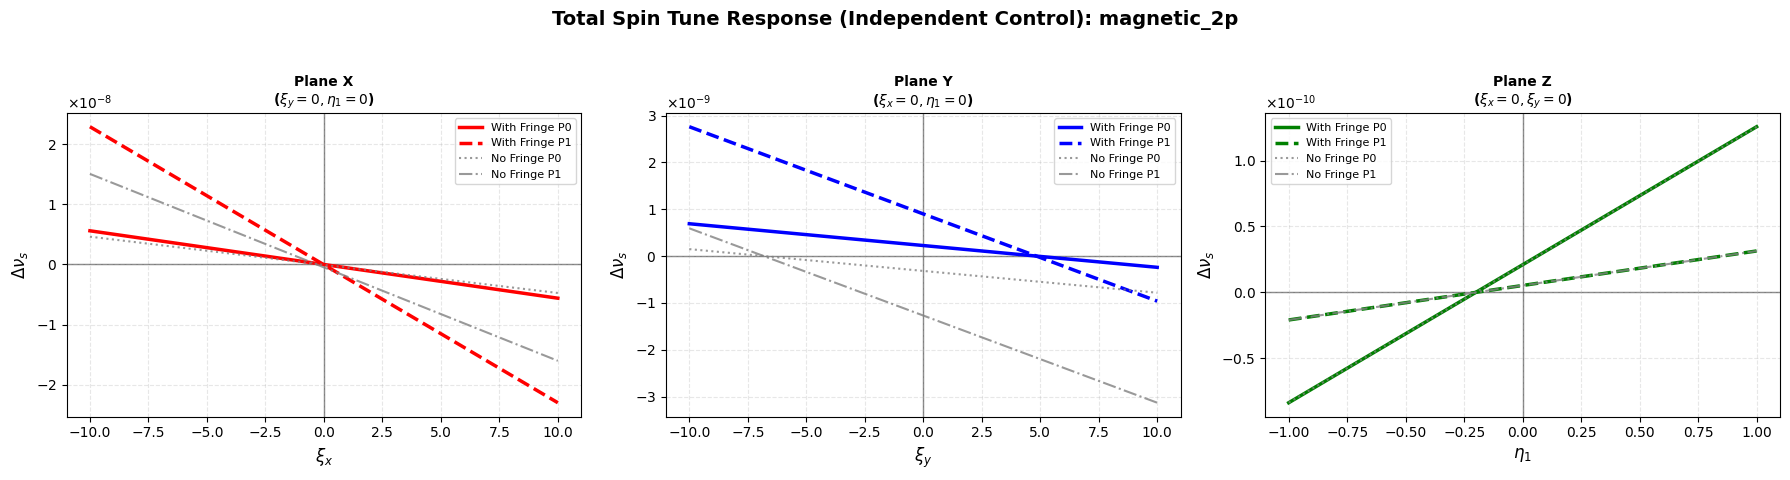

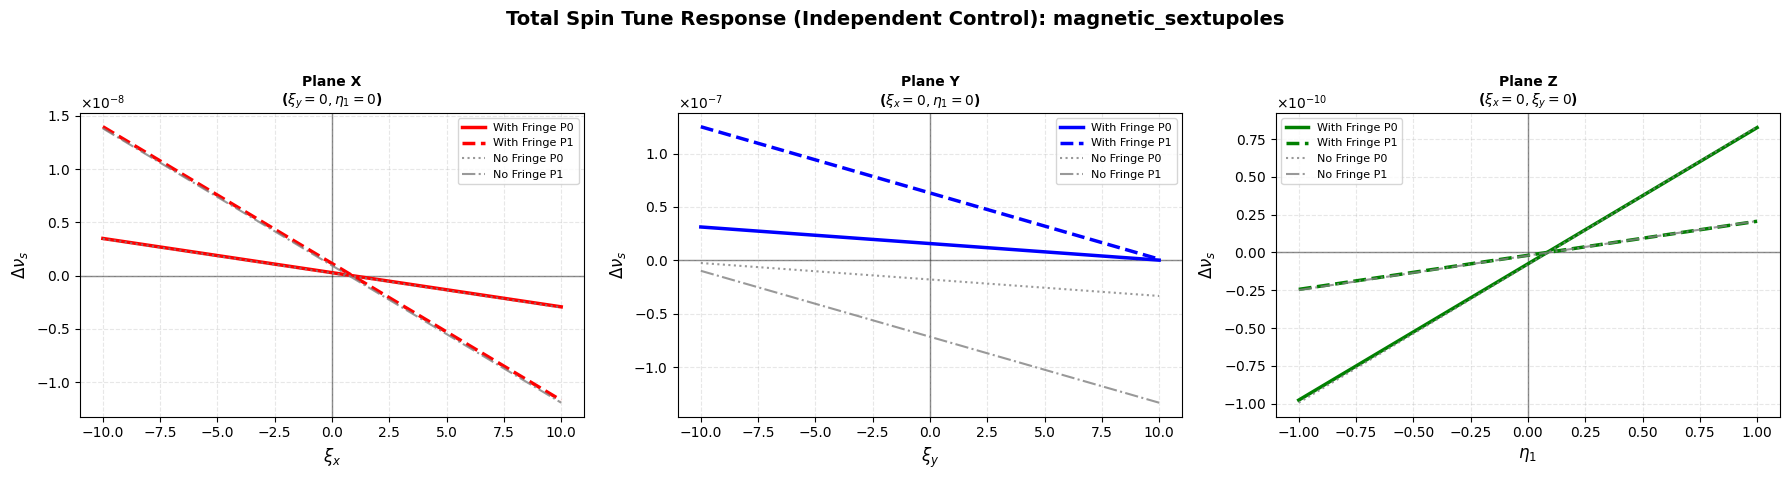

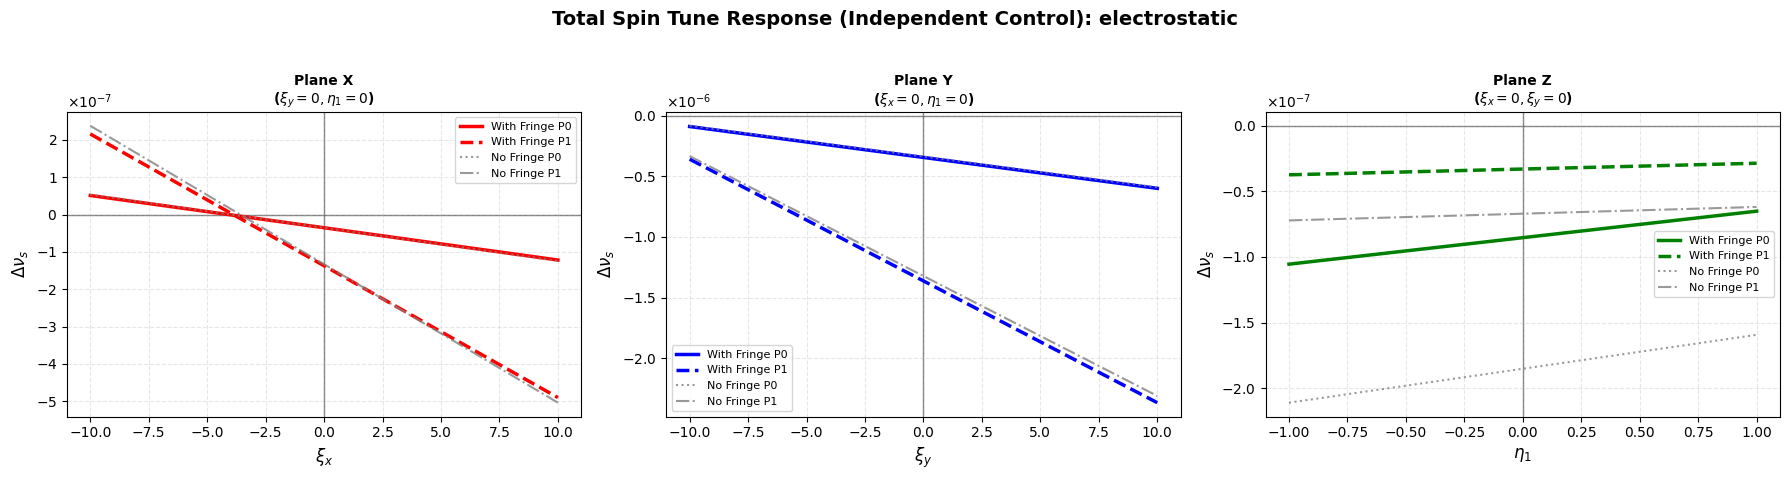

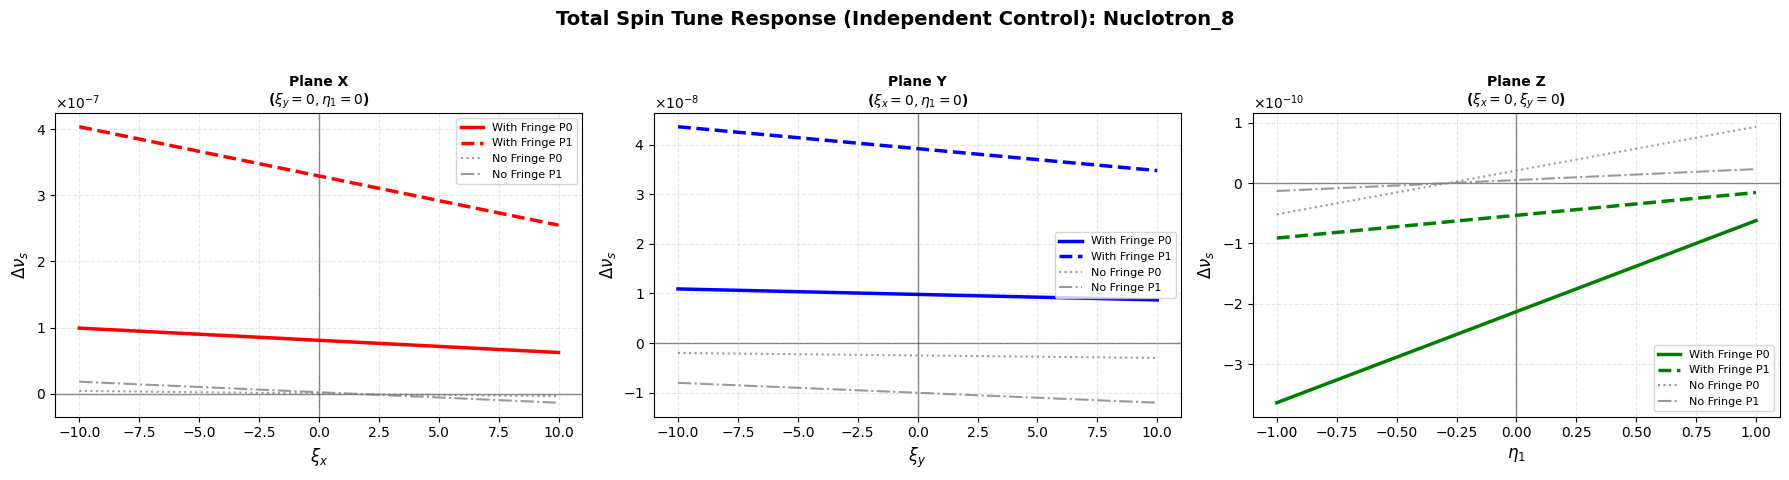

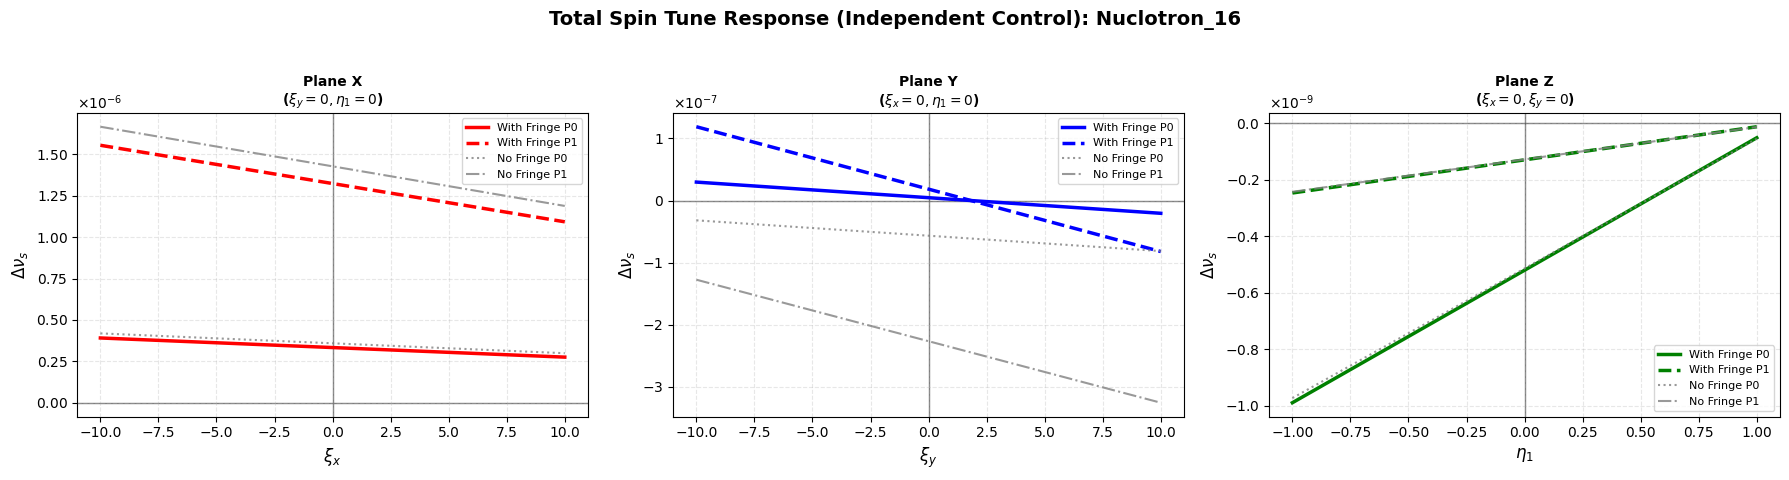

In [144]:
for lat in lattices:
    # Load data for the current lattice structure
    df_no_fr = get_data(lat, 'FR0') # Assumes get_data is defined
    df_with_fr = get_data(lat, 'FR3')
    if df_no_fr is None or df_with_fr is None: continue

    # --- Model Construction ---
    # Build independent R_spin and R_int models for every mode/particle combination
    lattice_models = {
        'NoFr_P0':   get_dual_model(df_no_fr, suffix=''),   
        'NoFr_P1':   get_dual_model(df_no_fr, suffix='_1'),
        'WithFr_P0': get_dual_model(df_with_fr, suffix=''), 
        'WithFr_P1': get_dual_model(df_with_fr, suffix='_1')
    }

    # Initialize the summary figure (1x3 grid)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Total Spin Tune Response (Independent Control): {lat}', fontsize=14, fontweight='bold')

    for i in range(3):
        ax = axes[i]
        res = {state: [] for state in lattice_models.keys()}

        for val in ranges[i]:
            # Set target chromaticity for the active plane; others forced to 0
            target_chrom = np.zeros(3)
            target_chrom[i] = val
            
            # --- INDEPENDENT SEXTUPOLE CONTROL CALCULATION ---
            # We determine the specific currents required for each lattice state
            
            # 1. Currents for 'No Fringe' configuration
            m_no_fr = lattice_models['NoFr_P0']
            try:
                I_no_fr = np.linalg.solve(m_no_fr['R_int'], target_chrom - m_no_fr['int_nat'])
            except np.linalg.LinAlgError:
                I_no_fr, _, _, _ = np.linalg.lstsq(m_no_fr['R_int'], target_chrom - m_no_fr['int_nat'], rcond=None)
            
            # 2. Currents for 'With Fringe' configuration
            m_with_fr = lattice_models['WithFr_P0']
            try:
                I_with_fr = np.linalg.solve(m_with_fr['R_int'], target_chrom - m_with_fr['int_nat'])
            except np.linalg.LinAlgError:
                I_with_fr, _, _, _ = np.linalg.lstsq(m_with_fr['R_int'], target_chrom - m_with_fr['int_nat'], rcond=None)

            # --- CALCULATE SPIN RESPONSE ---
            for state, model in lattice_models.items():
                # Assign the correct current vector based on the configuration
                current_I = I_no_fr if 'NoFr' in state else I_with_fr
                
                # nu_s = R_spin * I + spin_nat
                spin_tune = np.dot(model['R_spin'][i], current_I) + model['spin_nat'][i]
                res[state].append(spin_tune)

        # --- VISUALIZATION ---
        # Plot Fringe Fields (Main Focus)
        ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        
        # Plot Ideal Field (Reference)
        ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.8, label='No Fringe P0')
        ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.8, label='No Fringe P1')

        # Formatting: Zero axes, labels, and scientific notation
        ax.axhline(0, color='black', lw=1.0, alpha=0.5, zorder=0)
        ax.axvline(0, color='black', lw=1.0, alpha=0.5, zorder=0)
        ax.set_xlabel(labels[i], fontsize=12)
        ax.set_ylabel(r'$\Delta \nu_s$', fontsize=12)
        ax.set_title(f'Plane {plane_names[i].upper()}\n({constraints[i]})', fontweight='bold', fontsize=10)
        
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True); fmt.set_powerlimits((-2, 2))
        ax.yaxis.set_major_formatter(fmt)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(fontsize=8, loc='best')

        # --- EXPORT INDIVIDUAL PLOTS ---
        # Generate stand-alone PNGs for presentation slides
        t_fig, t_ax = plt.subplots(figsize=(6, 5))
        t_ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        t_ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        t_ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.6, label='No Fringe P0')
        t_ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.6, label='No Fringe P1')
        
        t_ax.axhline(0, color='black', lw=1.0, alpha=0.5)
        t_ax.axvline(0, color='black', lw=1.0, alpha=0.5)
        t_ax.set_xlabel(labels[i]); t_ax.set_ylabel(r'$\Delta \nu_s$')
        t_ax.set_title(f"{lat} | {plane_names[i].upper()}-Plane | {constraints[i]}", fontsize=11)
        
        t_ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        t_ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        t_ax.grid(True, alpha=0.3); t_ax.legend(fontsize=9, loc='best')

        save_path = os.path.join(root_path, lat, f"{lat}_compare_dual_control_{plane_names[i]}.png")
        t_fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(t_fig)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Pure Dynamic Response Analysis (Sensitivity Only)

This iteration focuses exclusively on the **Slopes** of the response, stripping away all static offsets. By manually setting the natural (intercept) terms to zero, we isolate the pure Jacobian-driven sensitivity of the system.

### 1. Removing the Intercepts (The "Natural" Components)
In this mathematical mode, we strictly set the natural vectors to zero:
*   **$\vec{b}_{spin} = [0, 0, 0]$** (Assuming zero baseline spin tune)
*   **$\vec{d}_{int} = [0, 0, 0]$** (Assuming zero baseline chromaticity)

### 2. Modified Response Equations
The general linear model is reduced to a **Homogeneous System**. We compare how the equations change:


| Component | Full Model (Static + Dynamic) | Pure Dynamic Model (Slopes Only) |
| :--- | :--- | :--- |
| **Currents ($I$)** | $\vec{I} = \mathbf{R}_{int}^{-1} \cdot (\vec{\xi}_{target} - \color{red}{\vec{d}_{int}})$ | $\vec{I} = \mathbf{R}_{int}^{-1} \cdot \vec{\xi}_{target}$ |
| **Spin Tune ($\nu_s$)** | $\vec{\nu}_{s} = \mathbf{R}_{spin} \cdot \vec{I} + \color{red}{\vec{b}_{spin}}$ | $\Delta\vec{\nu}_{s, pure} = \mathbf{R}_{spin} \cdot \vec{I}$ |

### 3. Visual Interpretation of the Change
*   **Mathematical Forcing**: By removing $\color{red}{\vec{d}_{int}}$ and $\color{red}{\vec{b}_{spin}}$, we eliminate the "Static Shift".
*   **The (0,0) Intersection**: Every single line for every particle (P0, P1) and every mode (With/Without Fringe) is now mathematically forced to pass exactly through the origin $(0,0)$.
*   **Pure Slope Analysis**: Any divergence between the lines now represents the **Pure Sensitivity Difference**. It shows how fringe fields change the "strength" of the sextupole-spin interaction without the distraction of initial frequency spreads.


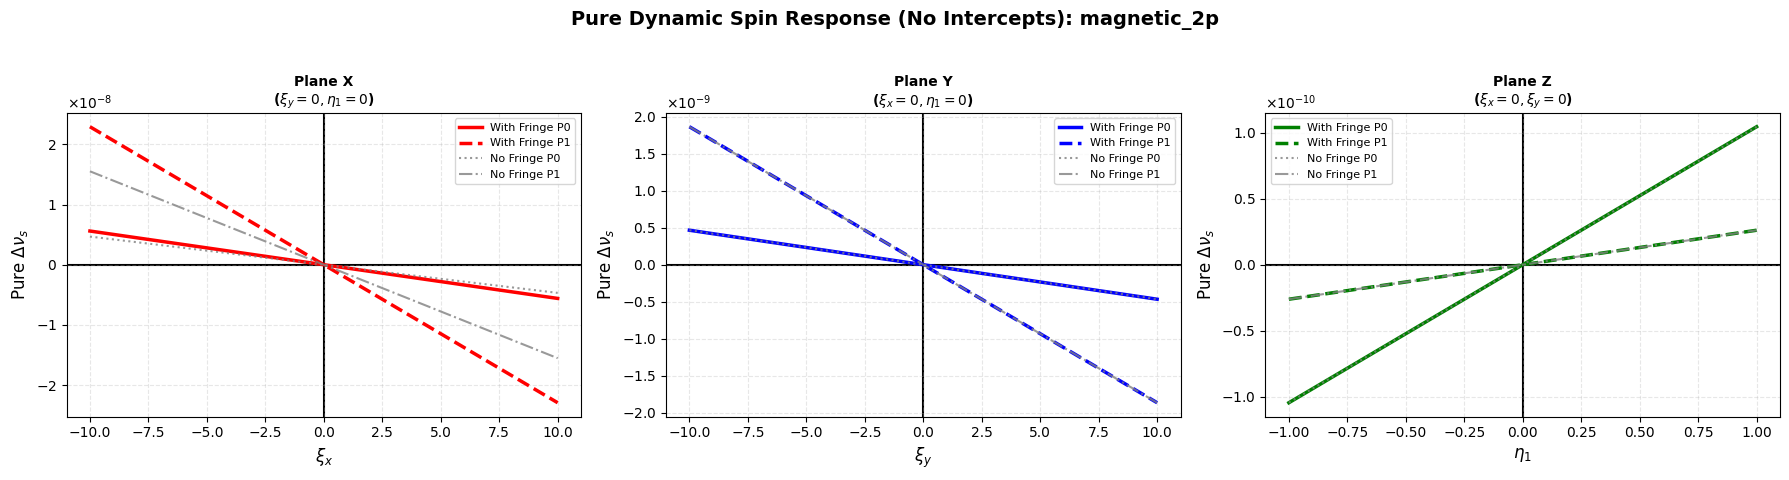

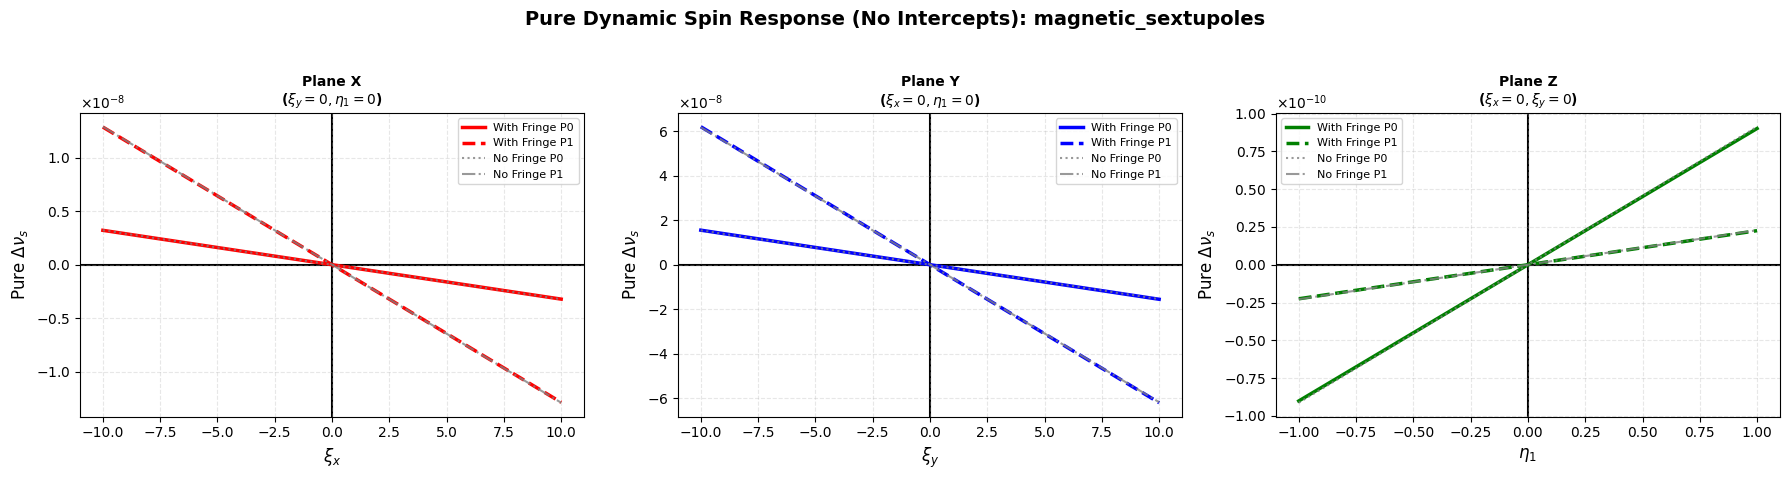

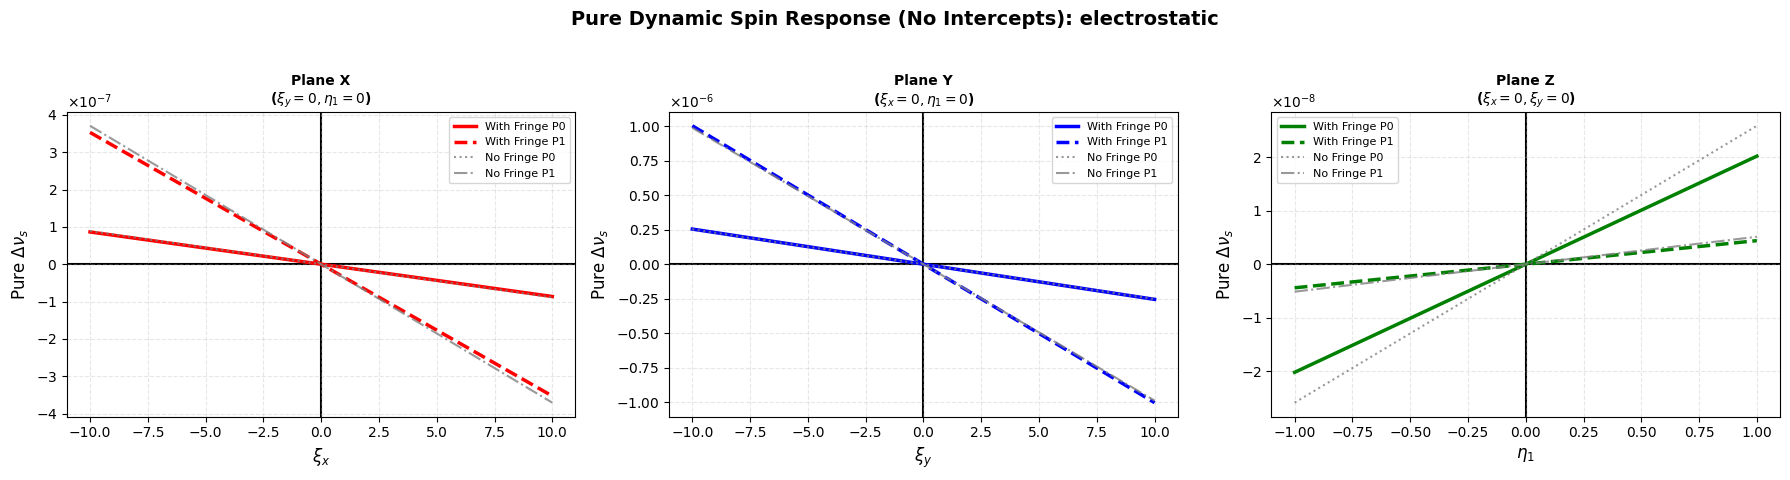

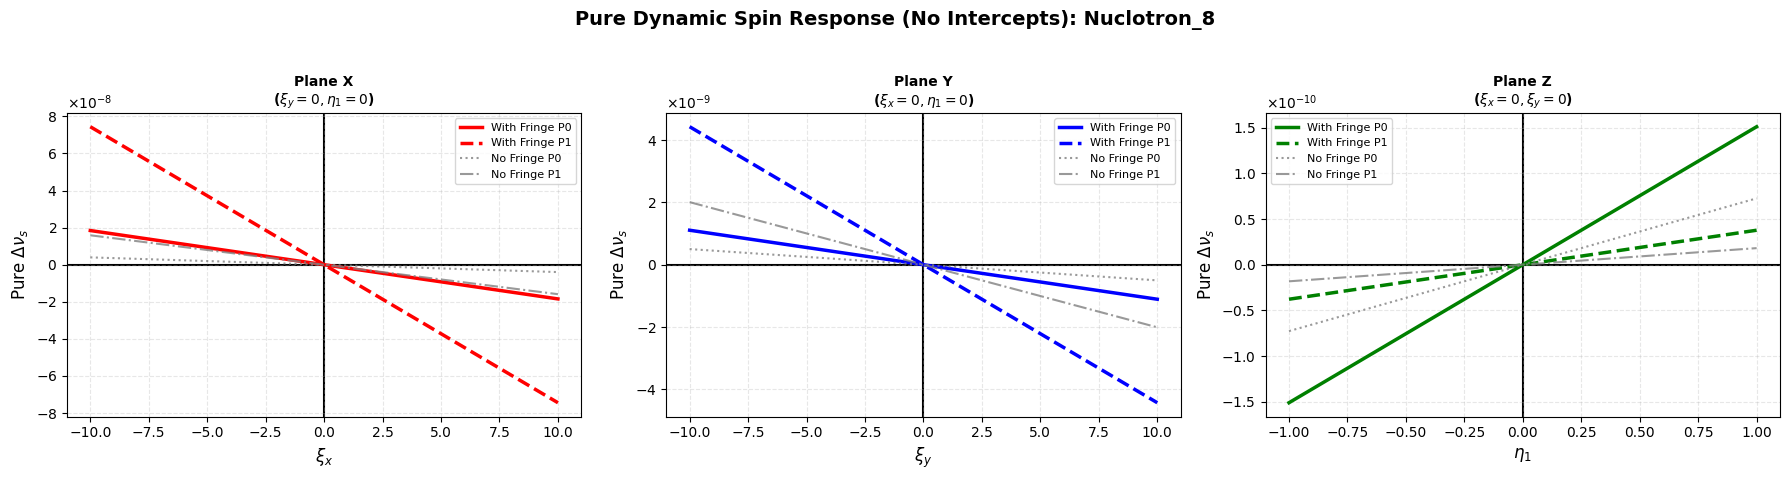

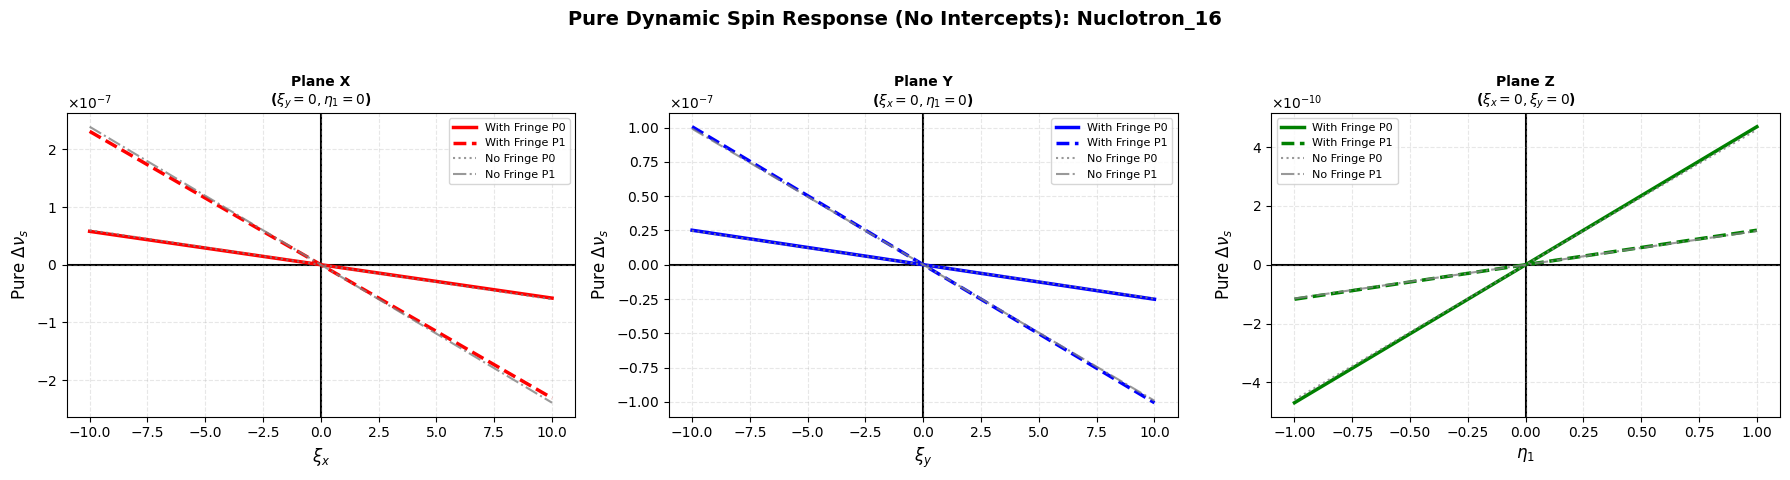

In [145]:
for lat in lattices:
    # Load data for the current lattice structure
    df_no_fr = get_data(lat, 'FR0') 
    df_with_fr = get_data(lat, 'FR3')
    if df_no_fr is None or df_with_fr is None: continue

    # --- Model Construction ---
    lattice_models = {
        'NoFr_P0':   get_dual_model(df_no_fr, suffix=''),   
        'NoFr_P1':   get_dual_model(df_no_fr, suffix='_1'),
        'WithFr_P0': get_dual_model(df_with_fr, suffix=''), 
        'WithFr_P1': get_dual_model(df_with_fr, suffix='_1')
    }

    # Initialize the summary figure (1x3 grid)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Pure Dynamic Spin Response (No Intercepts): {lat}', fontsize=14, fontweight='bold')

    for i in range(3):
        ax = axes[i]
        res = {state: [] for state in lattice_models.keys()}

        for val in ranges[i]:
            # Set target chromaticity for the active plane; others forced to 0
            target_chrom = np.zeros(3)
            target_chrom[i] = val
            
            # --- PURE CURRENT CALCULATION (int_nat ignored) ---
            # Finding currents required to change chromaticity from a zero base
            
            # 1. Currents for 'No Fringe' configuration
            m_no_fr = lattice_models['NoFr_P0']
            try:
                I_no_fr = np.linalg.solve(m_no_fr['R_int'], target_chrom)
            except np.linalg.LinAlgError:
                I_no_fr, _, _, _ = np.linalg.lstsq(m_no_fr['R_int'], target_chrom, rcond=None)
            
            # 2. Currents for 'With Fringe' configuration
            m_with_fr = lattice_models['WithFr_P0']
            try:
                I_with_fr = np.linalg.solve(m_with_fr['R_int'], target_chrom)
            except np.linalg.LinAlgError:
                I_with_fr, _, _, _ = np.linalg.lstsq(m_with_fr['R_int'], target_chrom, rcond=None)

            # --- PURE SPIN RESPONSE CALCULATION (spin_nat ignored) ---
            for state, model in lattice_models.items():
                # Assign the correct current vector based on the configuration
                current_I = I_no_fr if 'NoFr' in state else I_with_fr
                
                # nu_s_pure = R_spin * I (Linear slope only)
                spin_tune_pure = np.dot(model['R_spin'][i], current_I)
                res[state].append(spin_tune_pure)

        # --- VISUALIZATION ---
        ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.8, label='No Fringe P0')
        ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.8, label='No Fringe P1')

        # Formatting: Zero axes (essential for pure response), labels, and scientific notation
        ax.axhline(0, color='black', lw=1.5, zorder=0)
        ax.axvline(0, color='black', lw=1.5, zorder=0)
        ax.set_xlabel(labels[i], fontsize=12)
        ax.set_ylabel(r'Pure $\Delta \nu_s$', fontsize=12)
        ax.set_title(f'Plane {plane_names[i].upper()}\n({constraints[i]})', fontweight='bold', fontsize=10)
        
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True); fmt.set_powerlimits((-2, 2))
        ax.yaxis.set_major_formatter(fmt)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(fontsize=8, loc='best')

        # --- EXPORT INDIVIDUAL PLOTS ---
        t_fig, t_ax = plt.subplots(figsize=(6, 5))
        t_ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        t_ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        t_ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.6, label='No Fringe P0')
        t_ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.6, label='No Fringe P1')
        
        t_ax.axhline(0, color='black', lw=1.5)
        t_ax.axvline(0, color='black', lw=1.5)
        t_ax.set_xlabel(labels[i]); t_ax.set_ylabel(r'Pure $\Delta \nu_s$')
        t_ax.set_title(f"{lat} | {plane_names[i].upper()}-Plane | Sensitivity", fontsize=11)
        
        t_ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        t_ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        t_ax.grid(True, alpha=0.3); t_ax.legend(fontsize=9, loc='best')

        save_path = os.path.join(root_path, lat, f"{lat}_pure_dynamic_{plane_names[i]}.png")
        t_fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(t_fig)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()